# Lab 7- Data Analysis

## Excercise 1- Reading

## HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on Kaggle. Please read sections 1 and 3 (skip/skim 2) of The HiggsML Technical Documentation.

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms.

## SUSY Dataset
For the next few labs we will use datasets used in the first paper on Deep Learning in High Energy physics. Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.



## Excercise 2- Download SUSY Dataset
The information about the dataset can be found at the UCI Machine Learning Repository. We'll start with the SUSY Dataset.

## Download
In a terminal, download the data directly from the source and then decompress it. For example:

To download:

On Mac OS: curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

In linux: wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz

To uncompress: gunzip SUSY.csv.gz

In [ ]:
! curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

In [ ]:
!rm SUSY.csv

In [ ]:
!gunzip SUSY.csv.gz

In [ ]:
ls -lh

In [ ]:
## dont run these again ^^


In [ ]:
filename = "SUSY.csv"

!head -5 "SUSY.csv"

## Reducing the Dataset
This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [ ]:
!ls -lh

We see that we have 5 million datapoints.

In [ ]:
!wc -l SUSY.csv

We create a new file of the first half million. This is sufficient for our needs in this lab:

In [ ]:
!head -500000 SUSY.csv > SUSY-small.csv

In [ ]:
ls -lh

In [ ]:
! wc -l SUSY-small.csv

Use this file for the rest of the lab to make this run faster.

## First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are (based on documentation):

In [ ]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [ ]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [ ]:
RawNames

In [ ]:
FeatureNames

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [ ]:
filename = "SUSY-small.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [ ]:
df

The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [ ]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

# Exercise 3: Make nice figures
Now use matplotlib to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted matplotlib figures with multiple plots. Note that the plots in the paper are actually wrong!

In [ ]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="black",label="signal",density=1)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="red", label="background",density=1)
    plt.legend(loc='upper right')
    plt.show()

# Exercise 4: Correlation

## Exercise 4.1
**Part a**
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use seaborn.

**Part b**
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

**Part c**
Which observables appear to be best for separating signal from background?

In [ ]:
## low level = first few columns
## high level = hysics quantities

In [ ]:
print(df.columns)

In [ ]:
features = df.columns[1:6]
n_columns = len(features)
fig, axes = plt.subplots(n_columns,n_columns, figsize=(10,10))

for i, row_feature in enumerate(features):
    for j, col_feature in enumerate(features):
        ax = axes[i,j]

        if i == j:
            ax.hist(df[row_feature], bins = 30)
        else:
            ax.scatter(df[col_feature], df[row_feature], s=5, alpha = 0.5)


        if i == n_columns-1:
            ax.set_xlabel(col_feature)
        if j == 0:
            ax.set_ylabel(row_feature)
    
        

In [ ]:
features = df.columns[7:18]
n_columns = len(features)
fig, axes = plt.subplots(n_columns,n_columns, figsize=(10,10))

for i, row_feature in enumerate(features):
    for j, col_feature in enumerate(features):
        ax = axes[i,j]

        if i == j:
            ax.hist(df[row_feature], bins = 30)
        else:
            ax.scatter(df[col_feature], df[row_feature], s=5, alpha = 0.5)


        if i == n_columns-1:
            ax.set_xlabel(col_feature)
        if j == 0:
            ax.set_ylabel(row_feature)
    
        

- A different method of creating histograms could be to separate histogram and scatterplot data sets

In [ ]:
histogram_df = df.sample(50000, random_state = 42)
scatter_df = df.sample(2000, random_state = 42)







features = df.columns[1:6]
n_columns = len(features)
fig, axes = plt.subplots(n_columns,n_columns, figsize=(10,10))

for i, row_feature in enumerate(features):
    for j, col_feature in enumerate(features):
        ax = axes[i,j]

        if i == j:
            ax.hist(histogram_df[row_feature], bins = 30)
        else:
            ax.scatter(scatter_df[col_feature], scatter_df[row_feature], s=5, alpha = 0.5)


        if i == n_columns-1:
            ax.set_xlabel(col_feature)
        if j == 0:
            ax.set_ylabel(row_feature)
    
        

In [ ]:
histogram_df = df.sample(50000, random_state = 42)
scatter_df = df.sample(2000, random_state = 42)







features = df.columns[7:18]
n_columns = len(features)
fig, axes = plt.subplots(n_columns,n_columns, figsize=(10,10))

for i, row_feature in enumerate(features):
    for j, col_feature in enumerate(features):
        ax = axes[i,j]

        if i == j:
            ax.hist(histogram_df[row_feature], bins = 30)
        else:
            ax.scatter(scatter_df[col_feature], scatter_df[row_feature], s=5, alpha = 0.5)


        if i == n_columns-1:
            ax.set_xlabel(col_feature)
        if j == 0:
            ax.set_ylabel(row_feature)
    
        

- signal represent change in amplitude of a wave over a time period
- M_TR_2 is best for separating background and signal

## Exercise 4.2
**Part a** 
Install tabulate.

**Part b** 
Use numpy to compute the covariance matrix and correlation matrix between all observabes, and separately between low and high-level features.

In [ ]:
np.cov(df[1:6])
np.corrcoef(df[1:6])

In [ ]:
np.cov(df[7:18])
np.corrcoef(df[7:18])

**Part C**
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

In [ ]:
# Import the tabulate module
## https://www.datacamp.com/tutorial/python-tabulate
from tabulate import tabulate

covariance_lower = np.cov(df[1:6])
coerrelation_lower = np.corrcoef(df[1:6])

headers = ['l_1_pT', 'l_1_eta', 'l_1_phi', 'l_2_pT', 'l_2_eta',
       'l_2_phi']

format_lower_cov = [[f"{val: .3g}" for val in row] for row in covariance_lower]

print(tabulate(format_lower_cov, headers = headers, tablefmt = "grid"))

In [ ]:
covariance_lower = np.cov(df[1:6])
correlation_lower = np.corrcoef(df[1:6])

headers = ['l_1_pT', 'l_1_eta', 'l_1_phi', 'l_2_pT', 'l_2_eta',
       'l_2_phi']

format_lower_corr = [[f"{val: .3g}" for val in row] for row in correlation_lower]

print(tabulate(format_lower_corr, headers = headers, tablefmt = "grid"))

In [ ]:
covariance_higher = np.cov(df[7:18])
correlation_higher = np.corrcoef(df[7:18])

headers = ['MET', 'MET_phi', 'MET_rel', 'axial_MET', 'M_R', 'M_TR_2',
       'R', 'MT2', 'S_R', 'M_Delta_R', 'dPhi_r_b', 'cos_theta_r1']

format_higher_corr = [[f"{val: .3g}" for val in row] for row in correlation_higher]

print(tabulate(format_higher_corr, headers = headers, tablefmt = "grid"))

In [ ]:
covariance_higher = np.cov(df[7:18])
correlation_higher = np.corrcoef(df[7:18])

headers = ['MET', 'MET_phi', 'MET_rel', 'axial_MET', 'M_R', 'M_TR_2',
       'R', 'MT2', 'S_R', 'M_Delta_R', 'dPhi_r_b', 'cos_theta_r1']

format_higher_cov = [[f"{val: .3g}" for val in row] for row in covariance_higher]

print(tabulate(format_higher_cov, headers = headers, tablefmt = "grid"))

**Part d**
Write a function that takes a dataset and appropriate arguments and performs steps b and c.


In [ ]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

In [ ]:
display(HTML(tabulate.tabulate(format_higher_cov, tablefmt='html',headers= ['MET', 'MET_phi', 'MET_rel', 'axial_MET', 'M_R', 'M_TR_2',
       'R', 'MT2', 'S_R', 'M_Delta_R', 'dPhi_r_b', 'cos_theta_r1'])))

In [ ]:
display(HTML(tabulate.tabulate(format_higher_corr, tablefmt='html',headers= ['MET', 'MET_phi', 'MET_rel', 'axial_MET', 'M_R', 'M_TR_2',
       'R', 'MT2', 'S_R', 'M_Delta_R', 'dPhi_r_b', 'cos_theta_r1'])))

In [ ]:
display(HTML(tabulate.tabulate(format_lower_corr, tablefmt='html',headers= ['l_1_pT', 'l_1_eta', 'l_1_phi', 'l_2_pT', 'l_2_eta',
       'l_2_phi'])))

In [ ]:
display(HTML(tabulate.tabulate(format_lower_cov, tablefmt='html',headers= ['l_1_pT', 'l_1_eta', 'l_1_phi', 'l_2_pT', 'l_2_eta',
       'l_2_phi'])))

# Exercise 5: Selection
## Exercise 5.1
Part a By looking at the signal/background distributions for each observable (e.g. x) determine which selection criteria would be optimal:
1. x > x_c
2. x < x_c
3. |x-mu| > x_c
4. |x-mu| < x_c
where x_c is value to be determined below.

## Exercise 5.2
Plot the True Positive Rate (TPR) (aka signal efficiency ) and False Positive Rate (FPR) (aka background efficiency ) as function of 
x_c for applying the strategy in part a to each observable.

## Exercice 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:
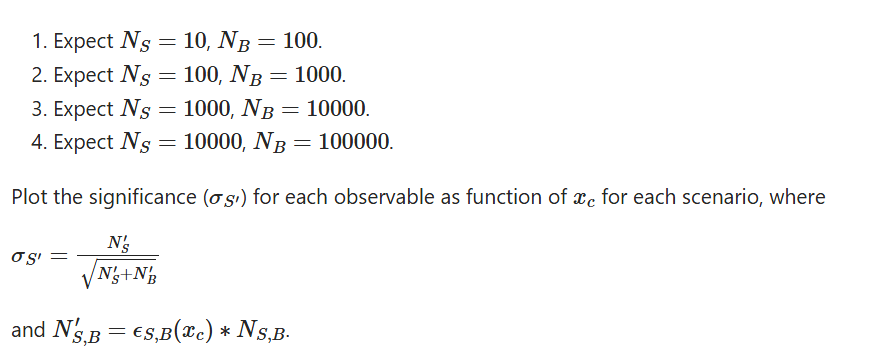

In [ ]:
def compute_rate(d,bins=100):
    hist,bins_=np.histogram(d,bins=bins,density=True)
    R = np.cumsum(hist[::-1])[::-1] * (bins_[1]-bins_[0])
    return R,bins_

In [ ]:
def compare_significance(df_sig, df_bkg,
                         obs_name,
                         scenarios,bins=100,log=False):
        
    TPR,bins_sig = compute_rate(df_sig[obs_name],bins=bins)
    FPR,bins_sig = compute_rate(df_bkg[obs_name],bins=bins_sig)
    
    max_sigs=dict()
    table=list()
    
    for name, (n_sig_expected, n_bkg_expected) in scenarios.items():

        n_sig_expected_prime = n_sig_expected * TPR
        n_bkg_expected_prime = n_bkg_expected * FPR

        sig = n_sig_expected_prime/ np.sqrt(n_sig_expected_prime + n_bkg_expected_prime )
        plt.step(bins_sig[:-1],sig,label=name+" "+str((n_sig_expected, n_bkg_expected)))
    
        max_i=np.argmax(sig)
        max_sigs[name]=(max_i,n_sig_expected_prime[max_i],n_bkg_expected_prime[max_i],sig[max_i],bins_sig[max_i])
        table.append((name,n_sig_expected, n_bkg_expected, 
                      TPR[max_i],FPR[max_i],
                      n_sig_expected_prime[max_i],n_bkg_expected_prime[max_i],sig[max_i],bins_sig[max_i],max_i)
        )
    if log:
        plt.yscale("log")
    plt.legend()
    plt.show()
    
    display(HTML(tabulate.tabulate(table, tablefmt='html',
                                   headers=["Name",'N sig','N bkg',"TPR","FPR","N sig'","N bkg'",'sig','x_c',"bin i"])))
    return max_sigs

In [ ]:
scenarios = { "1": (10,100), 
              "2": (100,1000),
              "2.1": (200,2000),
              "2.2": (300,3000),
              "2.3": (400,4000),
              "2.4": (500,5000),
              "3": (1000,10000),
              "4": (10000,100000)
            }
_=compare_significance(df_sig,df_bkg,"M_TR_2",scenarios)

In [ ]:
my_obs= ['MET',
 'MET_phi',
 'MET_rel',
 'axial_MET',
 'M_R',
 'M_TR_2',
 'R',
 'MT2',
 'S_R',
 'M_Delta_R',
 'dPhi_r_b',
 'cos_theta_r1']

In [ ]:
for obs in my_obs:
    print(obs)
    _=compare_significance(df_sig,df_bkg,obs,scenarios)
    